# 테일러 급수 Taloy Series


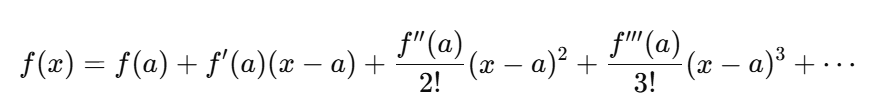

## 테일러 급수 정의


- 어떤 함수 f(x)를 다항식으로 비슷하게 만드는 것 (근사화, approximation)
- 함수의 무한급수 표현으로, 함수의 모든 도함수를 이용하여 특정 점에서의 함수값을 다항식으로 전개


#  sin함수의 테일러 급수 or 테일러 전개 (a = 0일때) -> 맥클로린 급수


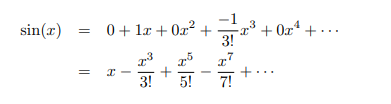

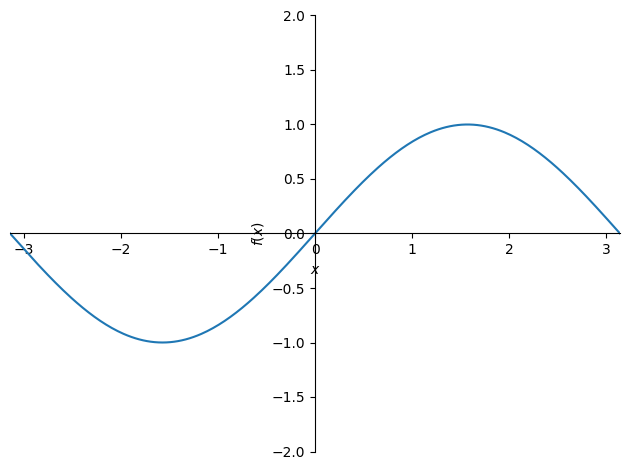

In [16]:
import sympy as sp

x = sp.symbols('x')

# sin함수 그리기

y = sp.sin(x)

sp.plot(y,xlim=(-sp.pi,sp.pi), ylim=(-2,2) ) # 그래프의 x범위, y범위 지정하기

In [ ]:
# 테일러 급수의 각 항

y1 = x  # 1차항
y2 = 0  # 2차항
y3 = (-x**3)/sp.factorial(3)  # 3차항
y5 = (x**5)/sp.factorial(5) # 5차항
y7 = (-x**7)/sp.factorial(7)  # 7차항
y9 = (x**9)/sp.factorial(9)
y11 = (-x**11)/sp.factorial(11)
y13 = (x**13)/sp.factorial(13)

# 테일러급수의 각 항이 의미하는 것을 시각적으로 시뮬레이션해보기

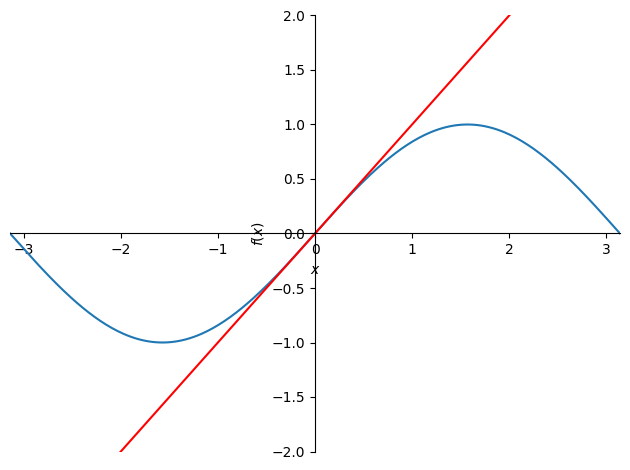

In [17]:
# sin함수와 테일러 급수로 표현한 sin함수 비교
p = sp.plot(y,y1,xlim=(-sp.pi,sp.pi), ylim=(-2,2), show = False) # 테일러 급수의 첫번째 항, show = False : 아직 보여주지 말고 hold하라는 의미.
p[1].line_color = 'r'  #2번째 함수의 그래프를 red로 표시
p.show()    # 모든게 다 정의가 됐으면 그래프를 출력하라는 명령어

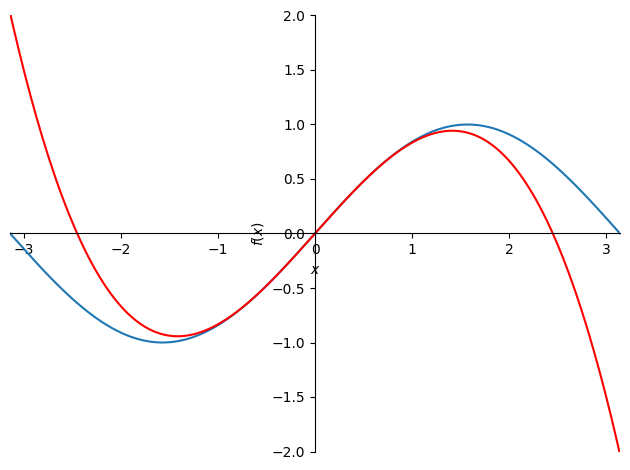

In [18]:
p = sp.plot(y,y1+y3,xlim=(-sp.pi,sp.pi), ylim=(-2,2), show = False) # 테일러 급수의 1,2번째 항
p[1].line_color = 'r'
p.show()

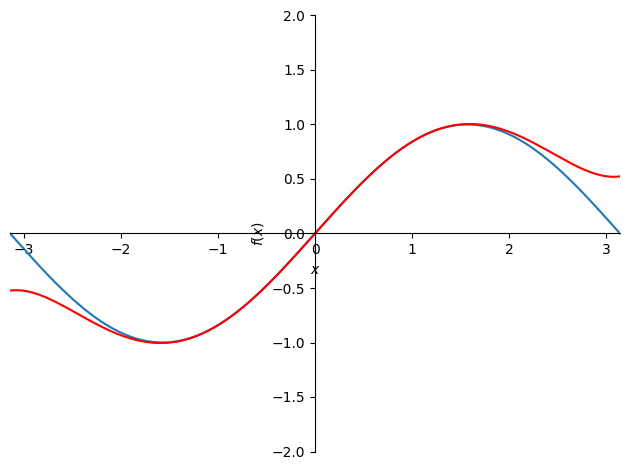

In [19]:
p = sp.plot(y,y1+y3+y5,xlim=(-sp.pi,sp.pi), ylim=(-2,2), show = False)# 테일러 급수의 1,2,3번째 항
p[1].line_color = 'r'
p.show()

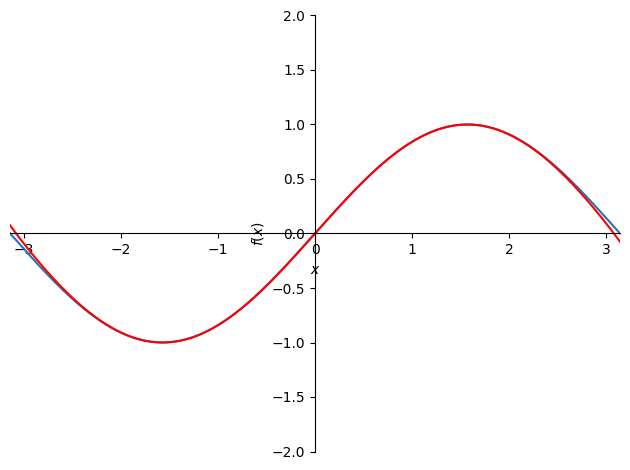

In [20]:
p = sp.plot(y,y1+y3+y5+y7,xlim=(-sp.pi,sp.pi), ylim=(-2,2), show = False) # 테일러 급수의 1,2,3,4번째 항
p[1].line_color = 'r'
p.show()

#  뉴마크 베타 법으로 실시간 구조물의 응답 시뮬레이션

In [22]:
import numpy as np
import matplotlib.pyplot as plt

Eq = np.loadtxt('elcentro.txt')


In [23]:
Eq


array([[ 0.0000000e+00, -1.4275799e-03],
       [ 2.0000000e-02, -1.1012760e-02],
       [ 4.0000000e-02, -1.0298970e-02],
       ...,
       [ 5.3700000e+01, -3.7728899e-03],
       [ 5.3720000e+01, -2.6512198e-03],
       [ 5.3740000e+01, -1.4275799e-03]])

In [26]:
import numpy as np
import matplotlib.pyplot as plt


M = np.array([[1]])  # Mass matrix
C = np.array([[0.05]])  # Damping matrix
K = np.array([[0.5]])  # Stiffness matrix

dof = len(M)
F = Eq[:,1]*9.81  # Force vector g to m/sec^2
F_eff = np.zeros((len(F), 1))  # Effective force vector

u0 = np.array([0])  # Initial displacement
v0 = np.array([0])  # Initial velocity
dt = Eq[1,0] - Eq[0,0]

gamma = 0.5
beta = 1/6



n_steps = len(F)
u = np.zeros((n_steps, dof))
v = np.zeros((n_steps, dof))
a = np.zeros((n_steps, dof))

du = np.zeros_like(u)
dv = np.zeros_like(v)
da = np.zeros_like(a)



In [27]:
# Initial conditions
u[0, :] = u0
v[0, :] = v0
a[0, :] = np.linalg.inv(M).dot(F[0] - C.dot(v0) - K.dot(u0))

# Effective stiffness matrix
K_eff = K + gamma / (beta * dt) * C + 1 / (beta * dt**2) * M

a1 = 1/beta/dt*M + gamma/beta*C
b1 = 1/2/beta*M+dt*(gamma/2/beta-1)*C


In [28]:
K_eff, a1, b1

(array([[15008.]]), array([[300.15]]), array([[3.0005]]))

In [29]:

for i in range(1, n_steps):

    # Effective force vector
    F_eff[i-1] = F[i] - F[i-1] + a1*v[i-1,:] + b1*a[i-1,:]

    # Solve for increments at each step
    du[i-1, :] = np.linalg.inv(K_eff).dot(F_eff[i-1])
    dv[i-1, :] = gamma/beta/dt*du[i-1,:]-gamma/beta*v[i-1,:]+dt*(1-gamma/2/beta)*a[i-1,:]
    da[i-1, :] = du[i-1, :]/(beta*(dt**2)) - v[i-1,:]/(beta*dt) - a[i-1,:]/(2*beta)

    # Solve for responses at next step
    u[i, :] = u[i-1, :] + du[i-1,:]
    v[i, :] = v[i-1, :] + dv[i-1,:]
    a[i, :] = a[i-1, :] + da[i-1,:]

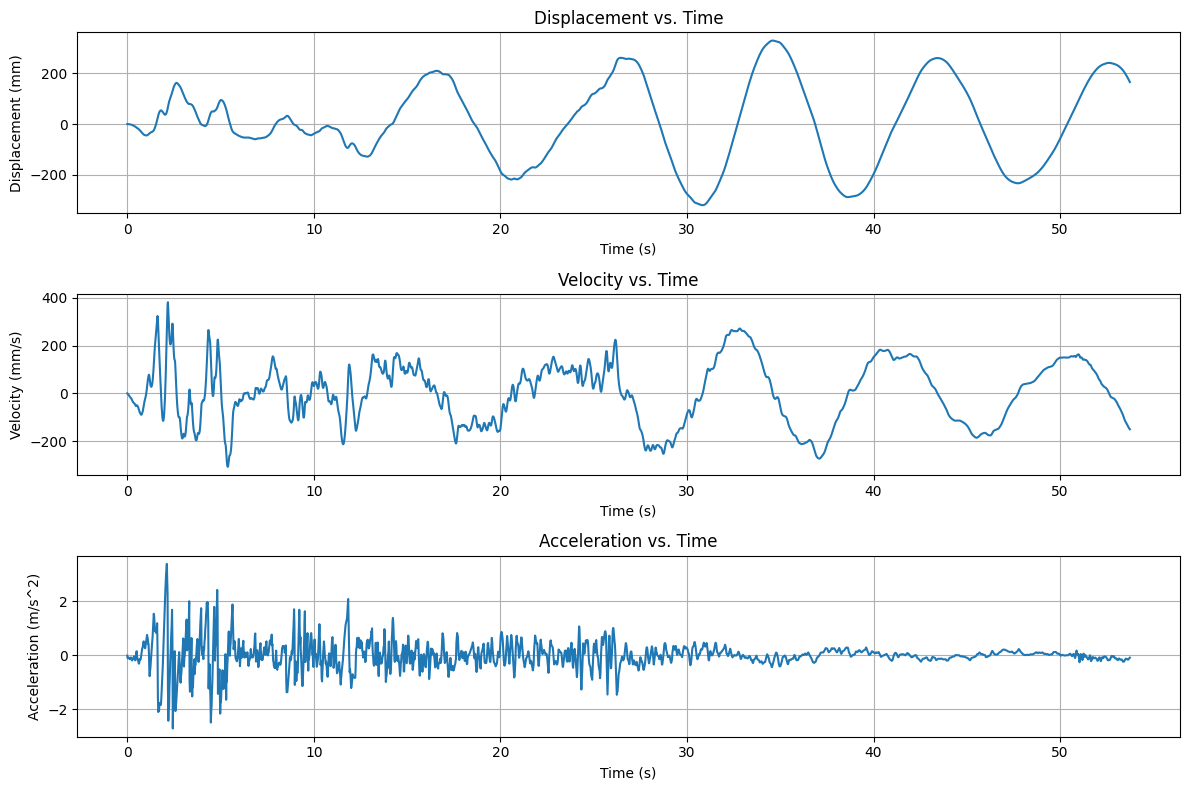

In [30]:
# Plotting results
time = np.linspace(0, dt * (len(u) - 1), len(u))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(time, u*1000)
plt.grid()
#plt.xlim(0, 12)
plt.title('Displacement vs. Time')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)')

plt.subplot(3, 1, 2)
plt.plot(time, v*1000)
plt.grid()
#plt.xlim(0, 12)
plt.title('Velocity vs. Time')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (mm/s)')

plt.subplot(3, 1, 3)
plt.plot(time, a)
#plt.xlim(0, 12)
plt.title('Acceleration vs. Time')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.grid()
plt.tight_layout()
plt.show()